In [ ]:
import h5py
import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial
from scipy.optimize import curve_fit

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader  # Make sure these are imported

from HubbardTweezer.Hubbard.lattice import sqr_lattice

from HubbardFit.tunneling import *
from HubbardFit.utils.funcs import *

# 4x4

In [ ]:
L = 4
grid = [L, L]
with h5py.File(f"../HubbardFit/data/{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array(grid))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

X = nnr[mask]
Y = nnt[mask]

# Example Usage
grid = [L, L]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")

3003
1187
Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 1 [[np.int64(2), np.int64(1)]]
Edge 3: [0 4] neighbors: 1 [[np.int64(4), np.int64(8)]]
Edge 4: [1 5] neighbors: 1 [[np.int64(5), np.int64(9)]]
Edge 5: [4 5] neighbors: 1 [[np.int64(5), np.int64(6)]]
Edge 6: [2 6] neighbors: 1 [[np.int64(6), np.int64(10)]]
Edge 7: [5 6] neighbors: 2 [[np.int64(5), np.int64(4)], [np.int64(6), np.int64(7)]]
Edge 8: [3 7] neighbors: 1 [[np.int64(7), np.int64(11)]]
Edge 9: [6 7] neighbors: 1 [[np.int64(6), np.int64(5)]]
Edge 10: [4 8] neighbors: 2 [[np.int64(4), np.int64(0)], [np.int64(8), np.int64(12)]]
Edge 11: [5 9] neighbors: 2 [[np.int64(5), np.int64(1)], [np.int64(9), np.int64(13)]]
Edge 12: [8 9] neighbors: 1 [[np.int64(9), np.int64(10)]]
Edge 13: [ 6 10] neighbors: 2 [[np.int64(6), np.int64(2)], [np.int64(10), np.int64(14)]]
Edge 14: [ 9 10] neighbors: 2 [[np.int64(9), np.int64

In [3]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = (
    torch.tensor(neighbor_counts, dtype=torch.float64)
    .unsqueeze(0)
    .repeat(X_torch["rij"].shape[0], 1)
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["d"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.9905
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.9432

Best L1 lambda from CV: 1.000e-05 (Avg R2: 0.9905)

Training final model with best L1 lambda: 1.000e-05
Final model training finished.
  Parameters (a_params): [-0.34487818 -6.85145846]
  Parameters (b_params): [0.40888647 9.30687211]
  Final Model Total Loss (MSE_norm + L1): 0.008634
  Final Model Normalized MSE part: 0.008465
  Final Model R2 on all data: 0.9915

Learned Exponential model equation (approx log(Y)):
  (-0.3449 * d + -6.8515) * X_rij + (0.4089 * d + 9.3069)


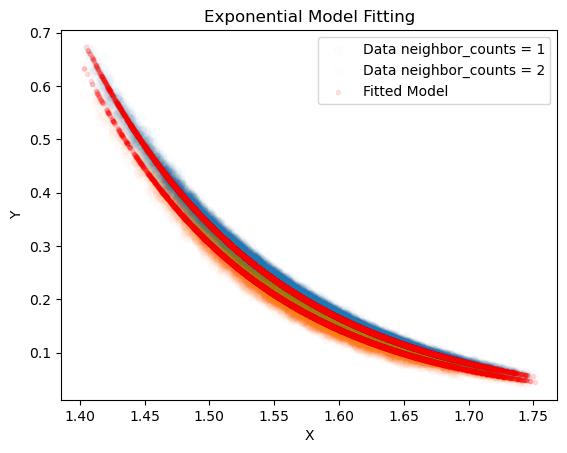

In [4]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_7990/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_7990/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.009507034075577122kHz')

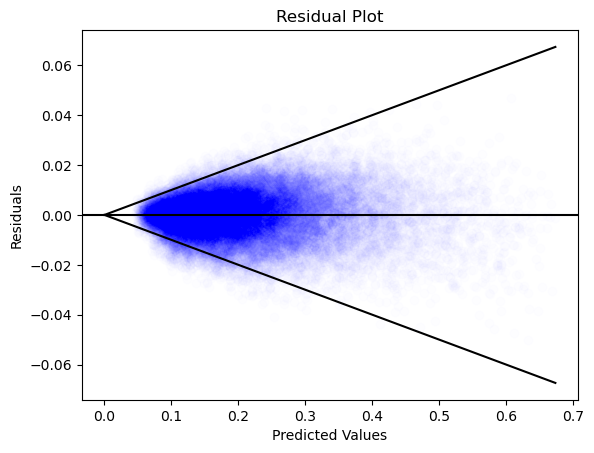

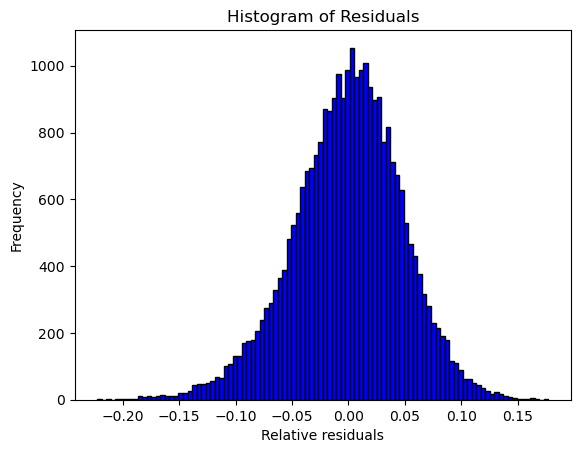

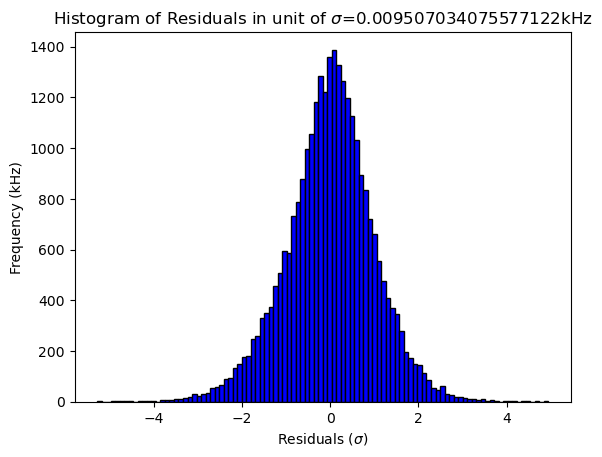

In [5]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

# 5x5

In [7]:
L = 5
grid = [L, L]
with h5py.File(f"data/{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array(grid))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

X = nnr[mask]
Y = nnt[mask]

# Example Usage
grid = [L, L]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")

1000
302
Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 2 [[np.int64(2), np.int64(1)], [np.int64(3), np.int64(4)]]
Edge 3: [3 4] neighbors: 1 [[np.int64(3), np.int64(2)]]
Edge 4: [0 5] neighbors: 1 [[np.int64(5), np.int64(10)]]
Edge 5: [1 6] neighbors: 1 [[np.int64(6), np.int64(11)]]
Edge 6: [5 6] neighbors: 1 [[np.int64(6), np.int64(7)]]
Edge 7: [2 7] neighbors: 1 [[np.int64(7), np.int64(12)]]
Edge 8: [6 7] neighbors: 2 [[np.int64(6), np.int64(5)], [np.int64(7), np.int64(8)]]
Edge 9: [3 8] neighbors: 1 [[np.int64(8), np.int64(13)]]
Edge 10: [7 8] neighbors: 2 [[np.int64(7), np.int64(6)], [np.int64(8), np.int64(9)]]
Edge 11: [4 9] neighbors: 1 [[np.int64(9), np.int64(14)]]
Edge 12: [8 9] neighbors: 1 [[np.int64(8), np.int64(7)]]
Edge 13: [ 5 10] neighbors: 2 [[np.int64(5), np.int64(0)], [np.int64(10), np.int64(15)]]
Edge 14: [ 6 11] neighbors: 2 [[np.int64(6), np.int64(

In [9]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = (
    torch.tensor(neighbor_counts, dtype=torch.float64)
    .unsqueeze(0)
    .repeat(X_torch["rij"].shape[0], 1)
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["d"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.9885
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.9505
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.9899
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.5988
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.9903

Best L1 lambda from CV: 1.000e-03 (Avg R2: 0.9903)

Training final model with best L1 lambda: 1.000e-03
Final model training finished.
  Parameters (a_params): [-0.46986123 -6.59317589]
  Parameters (b_params): [0.60139011 8.90845447]
  Final Model Total Loss (MSE_norm + L1): 0.025935
  Final Model Normalized MSE part: 0.009362
  Final Model R2 on all data: 0.9906

Learned Exponential model equation (approx log(Y)):
  (-0.4699 * d + -6.5932) * X_rij + (0.6014 * d + 8.9085)


Parameters are close to the 4x4 case. Mixed size training might do the trick.

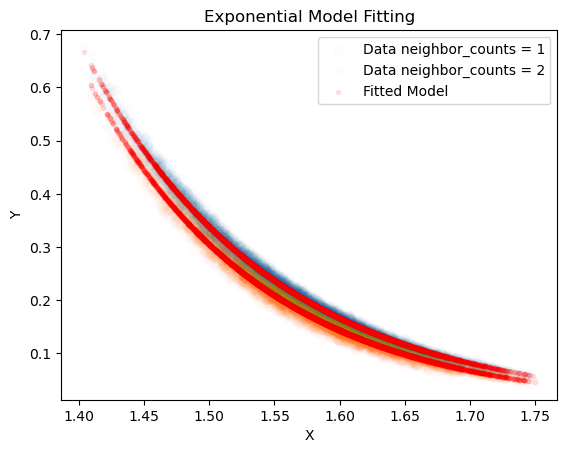

In [10]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_7990/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_7990/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.009825260160671097kHz')

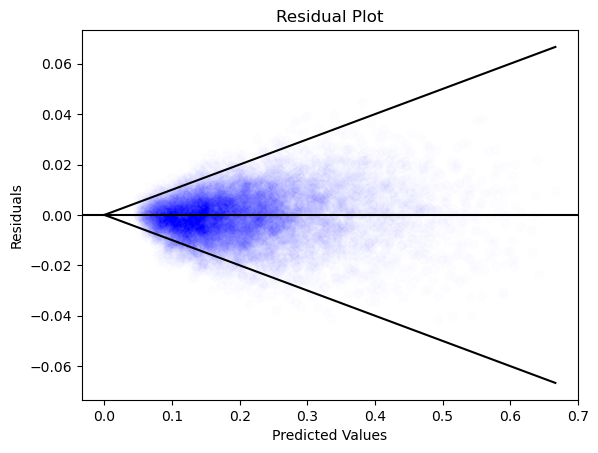

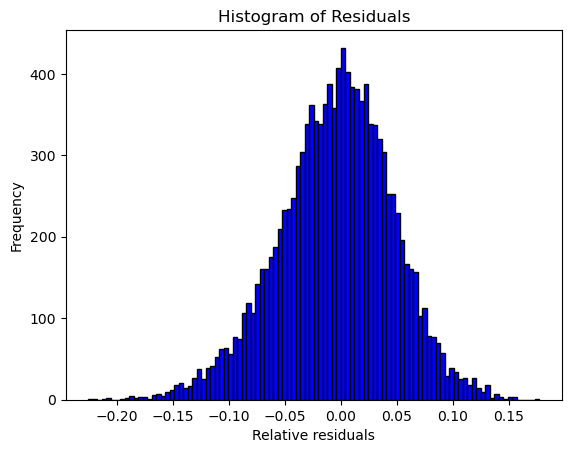

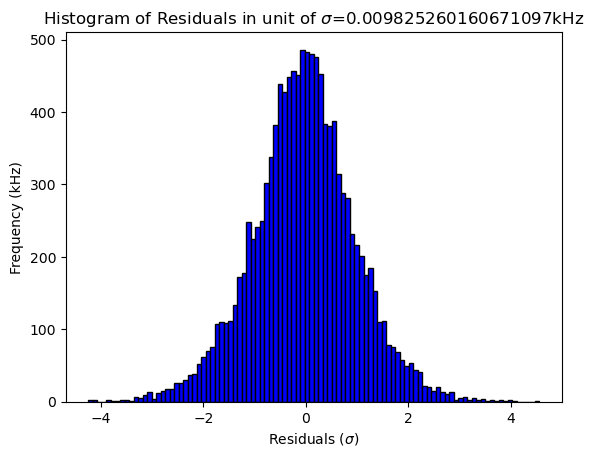

In [11]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

# 6x6

In [12]:
L = 6
grid = [L, L]
with h5py.File(f"data/{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array(grid))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

X = nnr[mask]
Y = nnt[mask]

# Example Usage
grid = [L, L]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")

1000
196
Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 2 [[np.int64(2), np.int64(1)], [np.int64(3), np.int64(4)]]
Edge 3: [3 4] neighbors: 2 [[np.int64(3), np.int64(2)], [np.int64(4), np.int64(5)]]
Edge 4: [4 5] neighbors: 1 [[np.int64(4), np.int64(3)]]
Edge 5: [0 6] neighbors: 1 [[np.int64(6), np.int64(12)]]
Edge 6: [1 7] neighbors: 1 [[np.int64(7), np.int64(13)]]
Edge 7: [6 7] neighbors: 1 [[np.int64(7), np.int64(8)]]
Edge 8: [2 8] neighbors: 1 [[np.int64(8), np.int64(14)]]
Edge 9: [7 8] neighbors: 2 [[np.int64(7), np.int64(6)], [np.int64(8), np.int64(9)]]
Edge 10: [3 9] neighbors: 1 [[np.int64(9), np.int64(15)]]
Edge 11: [8 9] neighbors: 2 [[np.int64(8), np.int64(7)], [np.int64(9), np.int64(10)]]
Edge 12: [ 4 10] neighbors: 1 [[np.int64(10), np.int64(16)]]
Edge 13: [ 9 10] neighbors: 2 [[np.int64(9), np.int64(8)], [np.int64(10), np.int64(11)]]
Edge 14: [ 5 11] neigh

In [13]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = (
    torch.tensor(neighbor_counts, dtype=torch.float64)
    .unsqueeze(0)
    .repeat(X_torch["rij"].shape[0], 1)
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["d"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.9881
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.9881
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.9881
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.9882
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.9886

Best L1 lambda from CV: 1.000e-03 (Avg R2: 0.9886)

Training final model with best L1 lambda: 1.000e-03
Final model training finished.
  Parameters (a_params): [-0.46899994 -6.58625206]
  Parameters (b_params): [0.59640632 8.90207371]
  Final Model Total Loss (MSE_norm + L1): 0.026175
  Final Model Normalized MSE part: 0.009621
  Final Model R2 on all data: 0.9904

Learned Exponential model equation (approx log(Y)):
  (-0.4690 * d + -6.5863) * X_rij + (0.5964 * d + 8.9021)


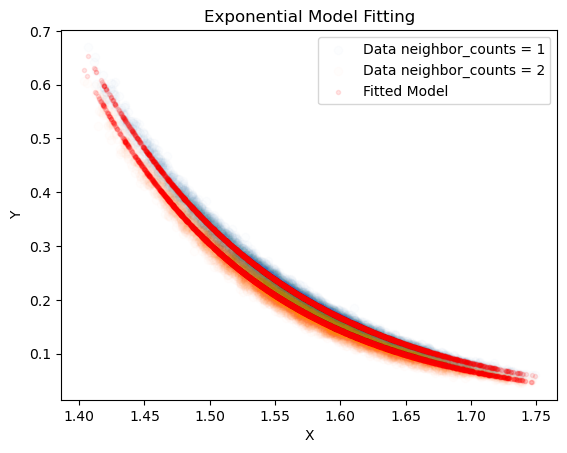

In [4]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_3830/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_3830/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.00986299043782425kHz')

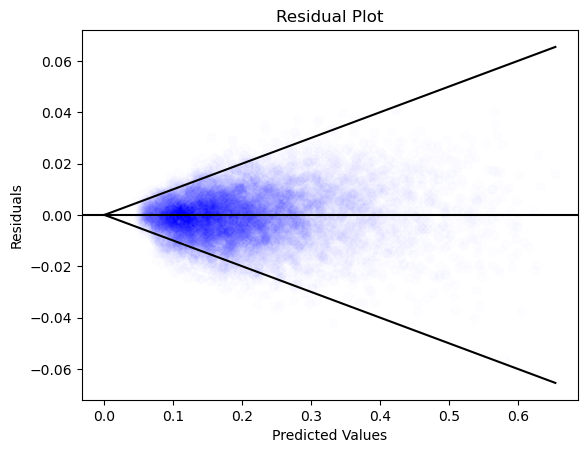

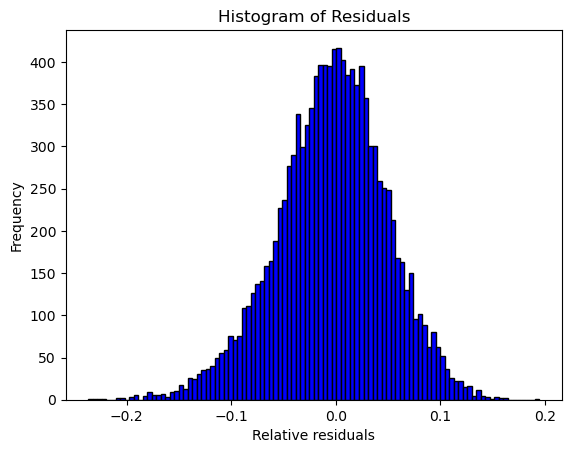

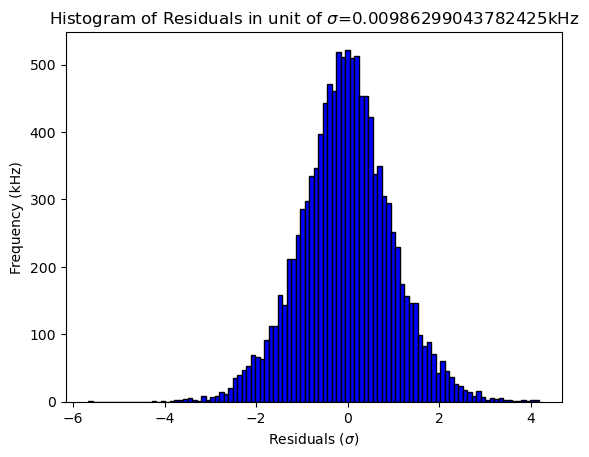

In [5]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

# 7x7

In [28]:
L = 7
grid = [L, L]
with h5py.File(f"data/{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array(grid))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

X = nnr[mask]
Y = nnt[mask]

# Example Usage
grid = [L, L]
edges = links

neighbor_counts, other_neighbor = get_neighbors(grid, edges)
for i in range(len(edges)):
    print(f"Edge {i}: {edges[i]} neighbors: {neighbor_counts[i]} {other_neighbor[i]}")

1000
99
Edge 0: [0 1] neighbors: 1 [[np.int64(1), np.int64(2)]]
Edge 1: [1 2] neighbors: 2 [[np.int64(1), np.int64(0)], [np.int64(2), np.int64(3)]]
Edge 2: [2 3] neighbors: 2 [[np.int64(2), np.int64(1)], [np.int64(3), np.int64(4)]]
Edge 3: [3 4] neighbors: 2 [[np.int64(3), np.int64(2)], [np.int64(4), np.int64(5)]]
Edge 4: [4 5] neighbors: 2 [[np.int64(4), np.int64(3)], [np.int64(5), np.int64(6)]]
Edge 5: [5 6] neighbors: 1 [[np.int64(5), np.int64(4)]]
Edge 6: [0 7] neighbors: 1 [[np.int64(7), np.int64(14)]]
Edge 7: [1 8] neighbors: 1 [[np.int64(8), np.int64(15)]]
Edge 8: [7 8] neighbors: 1 [[np.int64(8), np.int64(9)]]
Edge 9: [2 9] neighbors: 1 [[np.int64(9), np.int64(16)]]
Edge 10: [8 9] neighbors: 2 [[np.int64(8), np.int64(7)], [np.int64(9), np.int64(10)]]
Edge 11: [ 3 10] neighbors: 1 [[np.int64(10), np.int64(17)]]
Edge 12: [ 9 10] neighbors: 2 [[np.int64(9), np.int64(8)], [np.int64(10), np.int64(11)]]
Edge 13: [ 4 11] neighbors: 1 [[np.int64(11), np.int64(18)]]
Edge 14: [10 11] nei

In [7]:
# Data dimensions: (N, P, F)
# N: Number of main samples (e.g., systems, experiments)
# P: Number of pairs (data points) within each main sample
# F: Feature dimension (assumed to be 1 for rij and d in this model's formula)

# Convert data to torch tensors
X_torch = {}
X_torch["rij"] = torch.tensor(X, dtype=torch.float64)
X_torch["d"] = (
    torch.tensor(neighbor_counts, dtype=torch.float64)
    .unsqueeze(0)
    .repeat(X_torch["rij"].shape[0], 1)
)  # Ensure d is broadcastable to match rij shape
Y_torch = torch.tensor(Y, dtype=torch.float64)

num_main_samples = Y_torch.shape[0]  # N: e.g., 50 different experimental setups
num_pairs_per_sample = Y_torch.shape[1]  # P: e.g., 10 (rij,d) pairs within each setup
rij_dim = X_torch["rij"].shape[-1]  # F: Feature dimension for rij
d_dim = X_torch["d"].shape[-1]  # F: Feature dimension for d

device = "cpu"
print(f"Using device: {device}")

# Data does not need to be moved to device here if functions handle it,
# but good practice to do it once if all data fits.
# My functions move data to device per fold/run.

l1_lambdas_to_try = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
cv_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 25,
    "epochs": 25,
    "tol_grad": 1e-6,
    "tol_change": 1e-8,
    "tol_loss_change": 1e-8,
}

best_lambda, cv_scores = cross_validate_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    l1_lambdas=l1_lambdas_to_try,
    k_folds=3,  # Use 3-5 folds for CV
    lbfgs_params=cv_lbfgs_params,
    device=device,
)

final_train_lbfgs_params = {
    "lr": 0.01,
    "max_iter_per_step": 40,
    "epochs": 100,
    "tol_grad": 1e-8,
    "tol_change": 1e-10,
    "tol_loss_change": 1e-10,
}

final_trained_model = train_final_model_lbfgs(
    model_class=ExponentialModel,
    full_X_torch_dict=X_torch,
    full_Y_torch_tensor=Y_torch,
    best_l1_lambda=best_lambda,
    lbfgs_params=final_train_lbfgs_params,
    device=device,
)

learned_a = final_trained_model.a_params.data.cpu().numpy()
learned_b = final_trained_model.b_params.data.cpu().numpy()
print(f"\nLearned Exponential model equation (approx log(Y)):")
print(
    f"  ({learned_a[0]:.4f} * d + {learned_a[1]:.4f}) * X_rij + ({learned_b[0]:.4f} * d + {learned_b[1]:.4f})"
)

Using device: cpu
Starting Cross-Validation...
  L1 Lambda: 0.000e+00 -> Avg Validation R2: 0.9780
  L1 Lambda: 1.000e-06 -> Avg Validation R2: 0.9781
  L1 Lambda: 1.000e-05 -> Avg Validation R2: 0.9788
  L1 Lambda: 1.000e-04 -> Avg Validation R2: 0.9873
  L1 Lambda: 1.000e-03 -> Avg Validation R2: 0.9886

Best L1 lambda from CV: 1.000e-03 (Avg R2: 0.9886)

Training final model with best L1 lambda: 1.000e-03
Final model training finished.
  Parameters (a_params): [-0.49109143 -6.53912901]
  Parameters (b_params): [0.6307321 8.8281356]
  Final Model Total Loss (MSE_norm + L1): 0.027064
  Final Model Normalized MSE part: 0.010575
  Final Model R2 on all data: 0.9894

Learned Exponential model equation (approx log(Y)):
  (-0.4911 * d + -6.5391) * X_rij + (0.6307 * d + 8.8281)


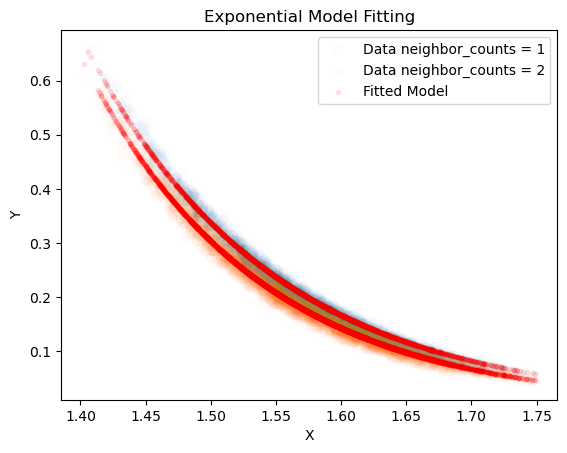

In [9]:
# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = final_trained_model(X_torch).numpy()

# Plotting the original data
for i in [1, 2]:
    plt.scatter(
        X[:, neighbor_counts == i],
        Y[:, neighbor_counts == i],
        label="Data neighbor_counts = " + str(i),
        alpha=1e-2,
    )

# Plotting the model's predictions
plt.scatter(X, predicted, color="red", label="Fitted Model", marker=".", alpha=0.1)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Exponential Model Fitting")
plt.legend()

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_3830/2242393529.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Residuals ($\sigma$)")
/var/folders/v_/57lcwyys42x6cnvvnbz7gk4h0000gn/T/ipykernel_3830/2242393529.py:52: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")


Text(0.5, 1.0, 'Histogram of Residuals in unit of $\\sigma$=0.010331320956298863kHz')

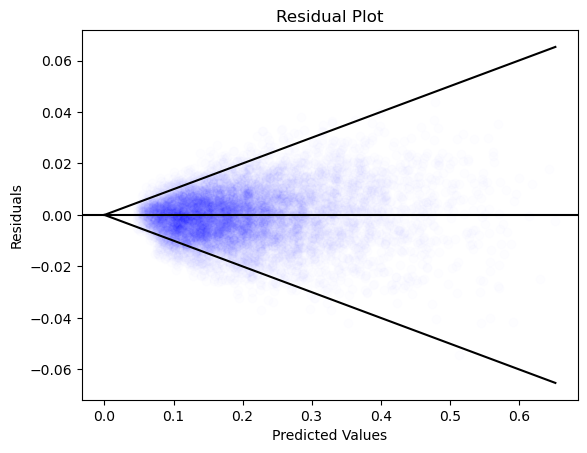

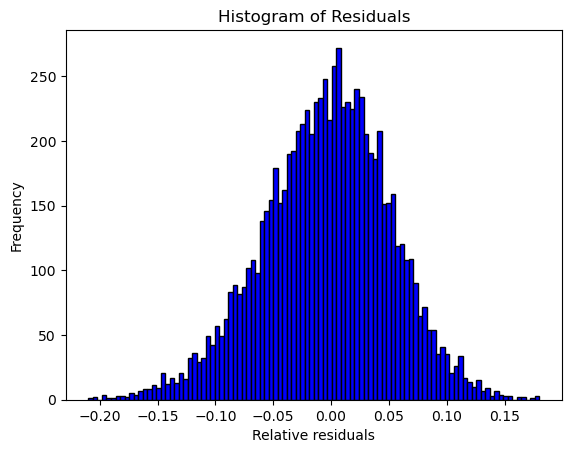

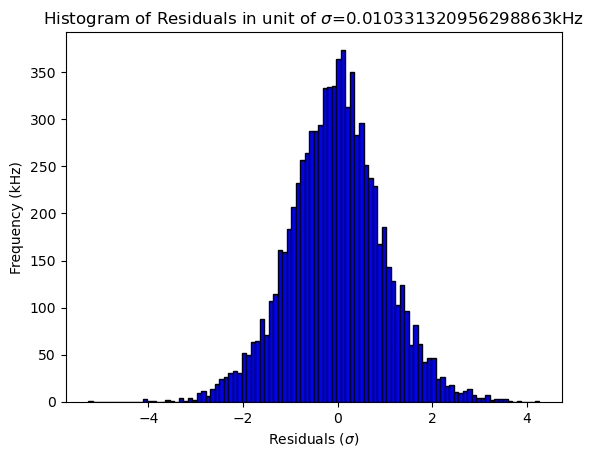

In [8]:
# Function to calculate residuals
def calculate_residuals(model, X, Y):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)
    residuals = Y - predictions
    return predictions, residuals


# Calculate residuals
predictions, residuals = calculate_residuals(final_trained_model, X_torch, Y_torch)

# Convert to numpy for plotting
predictions_np = predictions.numpy()
residuals_np = residuals.numpy()
sigma = np.std(residuals_np)

# Plotting residuals
plt.figure()
for i in [1, 2]:
    plt.scatter(
        predictions_np[:, neighbor_counts == i],
        residuals_np[:, neighbor_counts == i],
        color="blue",
        alpha=8e-3,
    )
plt.axhline(y=0, color="k", linestyle="-")
x = np.linspace(0, np.max(predictions_np), 100)
plt.plot(x, 0.1 * x, color="k")
plt.plot(x, -0.1 * x, color="k")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Optional: Histogram of Residuals
plt.figure()
plt.hist(
    residuals_np.flatten() / abs(predictions_np.flatten()),
    bins=100,
    color="blue",
    edgecolor="black",
)
plt.xlabel("Relative residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Optional: Histogram of Residuals ratio to sigma
plt.figure()
plt.hist(residuals_np.flatten() / sigma, bins=100, color="blue", edgecolor="black")
plt.xlabel("Residuals ($\sigma$)")
plt.ylabel("Frequency (kHz)")
plt.title(f"Histogram of Residuals in unit of $\sigma$={sigma}kHz")

# Mixed size training